In [1]:
import torchvision
import torch
torch.set_printoptions(sci_mode=False, precision=4)

# 1. Train Data Preprocessing 

### 1.1 60000 samples, 28x28 = 784 pixels MNIST Dataset

In [2]:
train = torchvision.datasets.MNIST("./data", download=True, train=True, transform=torchvision.transforms.ToTensor())
trainData = train.data.reshape(train.data.shape[0], -1)
trainData.shape, trainData[0]

(torch.Size([60000, 784]),
 tensor([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,
           0,   0,   0,  

### 1.2 Make it so that instead of binary, we have a normalized pixel from in range [0, 1], so that the data has dynamic of black and the model can learn it

In [3]:
trainData = trainData / 255
trainData[0]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

### 1.3 Visualize the normalized MNIST image (No information was lost)

In [4]:
import matplotlib.pyplot as plt

def plot_mnist(image, title="Image"):
    plt.imshow(image.detach().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

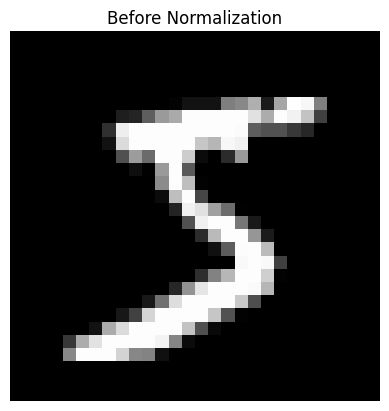

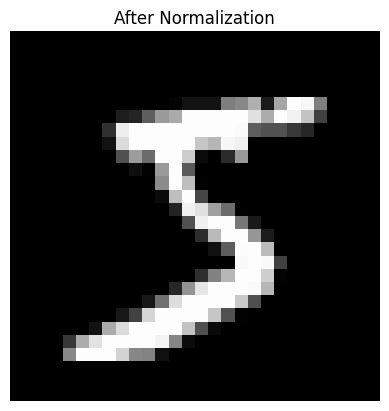

In [5]:
plot_mnist(train.data[0], "Before Normalization")

# Reshaping back into 28 x 28 before visualizing
plot_mnist(trainData[0].reshape(train.data.shape[1], -1), "After Normalization")


# 2. Defining VAE

In [6]:
# Latent Dimension, e.g. J=2, then encoder produces 2D multivariate guassian distribution parameters
# Pr(z | x) = N( (μ1, μ2), (σ1, σ2)I ) 
# Sample z 
J = 2

import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, J):
        super(Encoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 784))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(2*J, 500))
        self.b2 = nn.Parameter(torch.randn(2*J))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.tanh(self.w2 @ self.out + self.b2)
        return self.out

    def parameter(self):
        return [self.w1, self.b1, self.w2, self.b2]

class Reparametrizer(nn.Module):
    # R^(2J) -> R^J
    def __init__(self, J):
        super(Reparametrizer, self).__init__()

        self.J = J
        

    def forward(self, x):
        # Not Learnable, only for pure randomness
        epsilon = torch.randn(self.J)
        self.out = x[:J] + x[J:] * epsilon
        return self.out

    def parameter(self):
        return []


class Decoder(nn.Module):
    def __init__(self, J):
        super(Decoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 2))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(784, 500))
        self.b2 = nn.Parameter(torch.randn(784))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.sigmoid(self.w2 @ self.out + self.b2)
        return self.out


    def parameter(self):
        return [self.w1, self.b1, self.w2, self.b2]


In [7]:
# Full Training Loop
torch.manual_seed(42)

# VAE Configurations
J = 2 # Latent Dimension
training_step = 1000
batch_size = 32


e = Encoder(J)
r = Reparametrizer(J)
d = Decoder(J)

vaeParameters = e.parameter() + r.parameter() + d.parameter()

Losses = []


for i in range(training_step):

    # Mini Batch for SGD
    idx = torch.multinomial(torch.ones(train.data.shape[0]), 32)

    x = trainData[idx]

    # 1. Forward

    distParamZ = e(x)
    z = r(distParamZ)  
    decodedX = d(z)


    # 2. Calculate Loss

    meanVector = distParamZ[:J]
    stdVector = distParamZ[J:]
    KLLoss = 0.5 * (1 + torch.log(stdVector ** 2) - (meanVector ** 2) - (stdVector ** 2)).sum()
    safety = 1e-4
    DecoderLoss = ((trainData[0] * torch.log(decodedX + safety)) + ((1 - trainData[0]) * torch.log(1 - decodedX + safety))).sum()
    elbo = KLLoss + DecoderLoss
    Loss = -elbo

    print(f"{i:04d}th epoch: {Loss=}")
    Losses.append(Loss.data)


    # 3. Backward

    # 3.1 Flush Gradient
    for parameter in vaeParameters:
        parameter.grad = None
    
    # 3.2 Loss Backward
    Loss.backward()

    

    # 3.3 Update Parameters
    for parameter in vaeParameters:
        parameter.data -= 0.01 * parameter.grad


RuntimeError: mat1 and mat2 shapes cannot be multiplied (500x784 and 32x784)

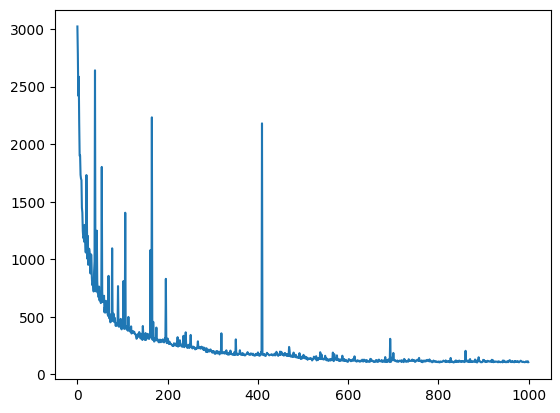

In [ ]:
plt.plot(Losses)

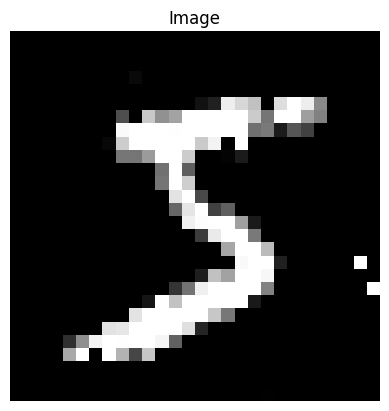

In [ ]:
# z ~ N(0, I), z is member of R^2 sampled from 2D multivariate gaussian distribution
z = torch.randn(2)
decodedX = d(z)

# Reshape the output
output = decodedX.reshape(train.data.shape[1], -1)
plot_mnist(output)

In [ ]:
a= torch.ones(100)
a

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
torch.multinomial(a, 5)

tensor([ 2, 13, 73, 69,  4])